# WISE Scaling Sweep — `best_effort_compilation_WISE` Validation

This notebook validates the **new** `best_effort_compilation_WISE` pipeline
against reference results from the old implementation.

| Old pipeline | New pipeline (`best_effort_compilation_WISE`) |
|---|---|
| `QCCDCircuit.generated()` | `stim.Circuit.generated()` |
| `QCCDCircuit.processCircuitWiseArch()` | `TrappedIonCompiler.compile()` (decompose → map → route → schedule) |
| `ionRoutingWISEArch()` | Called internally by `TrappedIonCompiler.route()` |
| `paralleliseOperationsWithBarriers()` | Called internally by `TrappedIonCompiler.schedule()` |
| `circuit.simulate()` | `TrappedIonExperiment.apply_hardware_noise()` + decode |
| `search_configs_best_exec_time()` (old env-var based) | `search_configs_best_exec_time()` (new, uses `WISERoutingConfig` / `WISESolverParams`) |
| `run_single_config()` (old) | `run_single_config()` (new, delegates to `_route_and_simulate`) |

**Key difference:** The new pipeline replaces environment-variable configuration
with proper `WISERoutingConfig` / `WISESolverParams` dataclasses, and uses
`TrappedIonCompiler` for the full decompose → map → route → schedule pipeline
instead of calling each step manually.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import stim
import multiprocessing as mp
import logging
import os
import matplotlib.pyplot as plt

# ── best_effort_compilation_WISE API ──
from qectostim.experiments.hardware_simulation.trapped_ion.utils.best_effort_compilation_WISE import (
    run_single_config,
    search_configs_best_exec_time,
    configure_wise_logging,
)

# ── Framework imports (architecture, config, constants) ──
from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture,
    TrappedIonCompiler,
    WISERoutingConfig,
    TrappedIonExperiment,
    TrappedIonNoiseModel,
    QCCDWiseArch,
    NDE_LZ,
    NDE_JZ,
    NSE_Z,
)

print("✅ All imports OK")

✅ All imports OK


## 1. Reference results from the old pipeline

These are the rows we want to reproduce (or validate against).

In [2]:
reference_rows = [
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.005659, 'comp_time': 24.08, 'logicalerror': 0.1161, 'reconfigTime': 0.003724},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.009787, 'comp_time': 52.86, 'logicalerror': 0.11893, 'reconfigTime': 0.007802},
    {'lookahead': 4, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.003674, 'comp_time': 110.04, 'logicalerror': 0.11533, 'reconfigTime': 0.001684},
    {'lookahead': 4, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.008348, 'comp_time': 481.84, 'logicalerror': 0.1162, 'reconfigTime': 0.006708},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.00484, 'comp_time': 25.70, 'logicalerror': 0.11693, 'reconfigTime': 0.00279},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.006913, 'comp_time': 43.01, 'logicalerror': 0.12043, 'reconfigTime': 0.004788},
    {'lookahead': 4, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.004725, 'comp_time': 81.66, 'logicalerror': 0.11599, 'reconfigTime': 0.00126},
    {'lookahead': 4, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.007868, 'comp_time': 242.87, 'logicalerror': 0.11741, 'reconfigTime': 0.004788},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.00401, 'comp_time': 11.58, 'logicalerror': 0.14691, 'reconfigTime': 0.00024},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.005032, 'comp_time': 88.12, 'logicalerror': 0.14807, 'reconfigTime': 0.001472},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006662, 'comp_time': 115.85, 'logicalerror': 0.15246, 'reconfigTime': 0.002892},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006662, 'comp_time': 118.21, 'logicalerror': 0.15252, 'reconfigTime': 0.002892},
    {'lookahead': 4, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.00401, 'comp_time': 16.60, 'logicalerror': 0.14715, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 8, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.00401, 'comp_time': 200.66, 'logicalerror': 0.14894, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006026, 'comp_time': 408.96, 'logicalerror': 0.14869, 'reconfigTime': 0.002256},
    {'lookahead': 4, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006026, 'comp_time': 383.40, 'logicalerror': 0.1481, 'reconfigTime': 0.002256},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 15.20, 'logicalerror': 0.20172, 'reconfigTime': 0.00024},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 15.95, 'logicalerror': 0.20172, 'reconfigTime': 0.00024},
    {'lookahead': 1, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004646, 'comp_time': 45.93, 'logicalerror': 0.20224, 'reconfigTime': 0.000876},
    {'lookahead': 1, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004646, 'comp_time': 45.63, 'logicalerror': 0.20611, 'reconfigTime': 0.000876},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005602, 'comp_time': 517.75, 'logicalerror': 0.2063, 'reconfigTime': 0.001832},
    {'lookahead': 1, 'subgrid_width': 16, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005465, 'comp_time': 489.45, 'logicalerror': 0.20222, 'reconfigTime': 0.00228},
    {'lookahead': 4, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 24.49, 'logicalerror': 0.20377, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 26.12, 'logicalerror': 0.20222, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 82.80, 'logicalerror': 0.20406, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00401, 'comp_time': 84.52, 'logicalerror': 0.20212, 'reconfigTime': 0.00024},
    {'lookahead': 4, 'subgrid_width': 16, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004295, 'comp_time': 1257.58, 'logicalerror': 0.20413, 'reconfigTime': 0.00075},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005602, 'comp_time': 2909.50, 'logicalerror': 0.20753, 'reconfigTime': 0.001832},
    {'lookahead': 4, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.00645, 'comp_time': 4944.66, 'logicalerror': 0.21236, 'reconfigTime': 0.00268},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.017909, 'comp_time': 304.64, 'logicalerror': 0.12658, 'reconfigTime': 0.015274},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.018858, 'comp_time': 326.80, 'logicalerror': 0.12538, 'reconfigTime': 0.015948},
    {'lookahead': 1, 'subgrid_width': 6, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.007649, 'comp_time': 574.15, 'logicalerror': 0.12347, 'reconfigTime': 0.005294},
    {'lookahead': 2, 'subgrid_width': 6, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.005983, 'comp_time': 943.81, 'logicalerror': 0.12113, 'reconfigTime': 0.003638},
    {'lookahead': 2, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.020869, 'comp_time': 2555.15, 'logicalerror': 0.12614, 'reconfigTime': 0.018114},
    {'lookahead': 2, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.0154, 'comp_time': 2397.12, 'logicalerror': 0.12658, 'reconfigTime': 0.01281},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.007601, 'comp_time': 274.74, 'logicalerror': 0.12564, 'reconfigTime': 0.004996},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.016049, 'comp_time': 415.55, 'logicalerror': 0.12602, 'reconfigTime': 0.012644},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.012681, 'comp_time': 1219.33, 'logicalerror': 0.12619, 'reconfigTime': 0.009366},
    {'lookahead': 2, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.007355, 'comp_time': 1208.36, 'logicalerror': 0.12493, 'reconfigTime': 0.00385},
    {'lookahead': 2, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.014753, 'comp_time': 2493.60, 'logicalerror': 0.12589, 'reconfigTime': 0.011928},
    {'lookahead': 2, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.011695, 'comp_time': 3295.28, 'logicalerror': 0.12621, 'reconfigTime': 0.00877},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.010951, 'comp_time': 129.13, 'logicalerror': 0.16841, 'reconfigTime': 0.005036},
    {'lookahead': 2, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.009595, 'comp_time': 200.85, 'logicalerror': 0.16362, 'reconfigTime': 0.00389},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.010444, 'comp_time': 419.38, 'logicalerror': 0.16624, 'reconfigTime': 0.005844},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.013531, 'comp_time': 818.18, 'logicalerror': 0.17206, 'reconfigTime': 0.008576},
    {'lookahead': 2, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.012024, 'comp_time': 978.31, 'logicalerror': 0.16938, 'reconfigTime': 0.006284},
    {'lookahead': 2, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.008804, 'comp_time': 782.12, 'logicalerror': 0.16368, 'reconfigTime': 0.004314},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.01385, 'comp_time': 368.67, 'logicalerror': 0.25774, 'reconfigTime': 0.00642},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.013243, 'comp_time': 1778.65, 'logicalerror': 0.24826, 'reconfigTime': 0.006788},
    {'lookahead': 1, 'subgrid_width': 11, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.010217, 'comp_time': 2107.74, 'logicalerror': 0.24456, 'reconfigTime': 0.004612},
    {'lookahead': 1, 'subgrid_width': 14, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.010247, 'comp_time': 3093.77, 'logicalerror': 0.24261, 'reconfigTime': 0.004612},
    {'lookahead': 1, 'subgrid_width': 16, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.00968, 'comp_time': 3167.34, 'logicalerror': 0.24593, 'reconfigTime': 0.00389},
    {'lookahead': 2, 'subgrid_width': 11, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.008537, 'comp_time': 1725.46, 'logicalerror': 0.24538, 'reconfigTime': 0.002062},
    {'lookahead': 1, 'subgrid_width': 6, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 3, 'n_traps': 6, 'trap_capacity': 2, 'exec_time': 0.009052, 'comp_time': 2505.56, 'logicalerror': 0.09198, 'reconfigTime': 0.006652},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 4, 'm_traps': 3, 'n_traps': 6, 'trap_capacity': 2, 'exec_time': 0.023509, 'comp_time': 6000.22, 'logicalerror': 0.09422, 'reconfigTime': 0.020184},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 2, 'n_traps': 6, 'trap_capacity': 4, 'exec_time': 0.010106, 'comp_time': 2548.55, 'logicalerror': 0.09664, 'reconfigTime': 0.006526},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 4, 'm_traps': 2, 'n_traps': 6, 'trap_capacity': 4, 'exec_time': 0.023838, 'comp_time': 5670.67, 'logicalerror': 0.09841, 'reconfigTime': 0.019468},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 1, 'n_traps': 6, 'trap_capacity': 8, 'exec_time': 0.017641, 'comp_time': 4707.32, 'logicalerror': 0.15234, 'reconfigTime': 0.010886},
    {'lookahead': 1, 'subgrid_width': 13, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 4, 'm_traps': 1, 'n_traps': 6, 'trap_capacity': 16, 'exec_time': 0.015482, 'comp_time': 5860.44, 'logicalerror': 0.26391, 'reconfigTime': 0.007912},
]

df_ref = pd.DataFrame(reference_rows)
print(f"Reference rows: {len(df_ref)}")
print(f"Distances:      {sorted(df_ref['d'].unique())}")
print(f"Trap capacities: {sorted(df_ref['trap_capacity'].unique())}")
df_ref.head(5)

Reference rows: 59
Distances:      [np.int64(2), np.int64(3), np.int64(4)]
Trap capacities: [np.int64(2), np.int64(4), np.int64(8), np.int64(16)]


,lookahead,subgrid_width,subgrid_height,subgrid_increment,d,m_traps,n_traps,trap_capacity,exec_time,comp_time,logicalerror,reconfigTime
0,1,4,3,0,2,2,3,2,0.005659,24.08,0.11610,0.003724
1,1,2,2,2,2,2,3,2,0.009787,52.86,0.11893,0.007802
2,4,4,3,0,2,2,3,2,0.003674,110.04,0.11533,0.001684
3,4,2,2,2,2,2,3,2,0.008348,481.84,0.11620,0.006708
4,1,4,3,0,2,1,3,4,0.004840,25.70,0.11693,0.002790


## 2. Sweep configuration

Translate the old script's knobs into the new framework.

In [3]:
# ─── Knobs (adjust as needed) ────────────────────────────
k_values              = [2]             # ions-per-trap
lookahead_values      = [4]             # SAT look-ahead depth
d_values              = [2]             # surface-code distance(s)
subgrid_area_values   = [12]            # requested subgrid areas (w*h)
increment_values      = [2]             # patch-growth increments
base_pmax_in          = 1               # SAT pmax
gate_improvements     = [1.0]           # error-scaling factors
num_shots             = 100_000         # simulation shots per config

RESULTS_CSV  = "wise_newpipeline_results.csv"
RESULTS_TXT  = RESULTS_CSV.replace(".csv", ".txt")
VERBOSE      = True

print("Sweep settings:")
print(f"  k            : {k_values}")
print(f"  lookahead    : {lookahead_values}")
print(f"  d values     : {d_values}")
print(f"  subgrid areas: {subgrid_area_values}")
print(f"  increments   : {increment_values}")
print(f"  num_shots    : {num_shots}")

Sweep settings:
  k            : [2]
  lookahead    : [4]
  d values     : [2]
  subgrid areas: [12]
  increments   : [2]
  num_shots    : 100000


## 3. Helper: compute full-grid dimensions

Identical logic to the old `_fullgrid_dims`.

In [4]:
def _fullgrid_dims(d: int, k: int):
    """Compute full WISE grid (W, H) for a rotated surface code."""
    nqubits_needed = 2 * d**2 - 1
    nrows_needed   = int(math.ceil(math.sqrt(nqubits_needed)))
    ncols_needed   = int(math.ceil(nrows_needed / k))
    eff_w = ncols_needed * k   # total columns
    eff_h = nrows_needed       # total rows
    return eff_w, eff_h


def _pick_wh_from_area(area: int, W_full: int, H_full: int):
    """Choose (w, h) that approximates the requested area."""
    area = int(max(1, area))
    ratio = W_full / H_full if H_full > 0 else 1.0
    w = int(max(1, round(math.sqrt(area * ratio))))
    h = int(max(1, area // max(1, w)))
    while (w * (h + 1)) <= area and (h + 1) <= H_full:
        h += 1
    w = min(max(1, w), W_full)
    h = min(max(1, h), H_full)
    while w * h > area and h > 1:
        h -= 1
    return w, h


# Quick sanity check
for d_test in [2, 3, 4]:
    for k_test in [2, 4, 8]:
        W, H = _fullgrid_dims(d_test, k_test)
        print(f"  d={d_test}, k={k_test} → full grid (W={W}, H={H}), "
              f"area={W*H}, m_traps={int(math.ceil(H/k_test))}, n_traps={H}")

  d=2, k=2 → full grid (W=4, H=3), area=12, m_traps=2, n_traps=3
  d=2, k=4 → full grid (W=4, H=3), area=12, m_traps=1, n_traps=3
  d=2, k=8 → full grid (W=8, H=3), area=24, m_traps=1, n_traps=3
  d=3, k=2 → full grid (W=6, H=5), area=30, m_traps=3, n_traps=5
  d=3, k=4 → full grid (W=8, H=5), area=40, m_traps=2, n_traps=5
  d=3, k=8 → full grid (W=8, H=5), area=40, m_traps=1, n_traps=5
  d=4, k=2 → full grid (W=6, H=6), area=36, m_traps=3, n_traps=6
  d=4, k=4 → full grid (W=8, H=6), area=48, m_traps=2, n_traps=6
  d=4, k=8 → full grid (W=8, H=6), area=48, m_traps=1, n_traps=6


## 4. Build config list & run the sweep

This mirrors the old sweep logic but calls `search_configs_best_exec_time()`
from `best_effort_compilation_WISE`.

In [5]:
rows = []
t0_all = time.time()

for d in d_values:
    for k in k_values:
        W_full, H_full = _fullgrid_dims(d, k)
        full_area = W_full * H_full
        m_traps = int(math.ceil(H_full / k))
        n_traps = H_full

        # ── build areas list (cap at full_area, append if missing) ──
        areas = sorted(a for a in set(subgrid_area_values) if a <= full_area)
        if not areas or areas[-1] < full_area:
            areas.append(full_area)

        area_to_wh = {A: _pick_wh_from_area(A, W_full, H_full) for A in areas}

        if VERBOSE:
            print(f"\n[d={d}, k={k}] full grid (W={W_full}, H={H_full}), "
                  f"full area={full_area}, m={m_traps}, n={n_traps}")
            for A, (w, h) in area_to_wh.items():
                eff = min(w, W_full) * min(h, H_full)
                tag = " (full-grid)" if (w >= W_full and h >= H_full) else ""
                print(f"  A={A:>6d} → (w={w}, h={h}), eff_area={eff}{tag}")

        # ── enumerate configs ──
        configs = []
        for la in lookahead_values:
            for A in areas:
                w, h = area_to_wh[A]
                eff_w = int(min(w, W_full))
                eff_h = int(min(h, H_full))
                is_fullgrid = (w >= W_full and h >= H_full)
                use_incs = [0] if is_fullgrid else [
                    inc for inc in increment_values
                    if (w + inc <= W_full or h + inc <= H_full)
                ]
                if not use_incs:
                    use_incs = [0]
                for inc in use_incs:
                    cfg = (la, eff_w, eff_h, inc)
                    if cfg not in configs:
                        configs.append(cfg)

        if VERBOSE:
            print(f"  configs to run: {configs}")

        # ── search via best_effort_compilation_WISE ──
        try:
            cores = mp.cpu_count()
            # Parallel execution with queue-based progress reporting
            # Both progress bars (outer config + inner SAT) will display
            best, all_res = search_configs_best_exec_time(
                configs,
                d=d,
                m_traps=m_traps,
                n_traps=n_traps,
                trap_capacity=k,
                base_pmax_in=1,
                max_total_workers=cores,  # Parallel: queue-based progress
                verbose=True,
                gate_improvements=gate_improvements,
                num_shots=num_shots,
                show_progress=True
            )
            if best is not None:
                print(f"  ✅ best exec_time = {best['exec_time']:.6f}")
            for res in all_res:
                rows.append(res)
        except Exception as e:
            print(f"  ❌ ERROR: {e}")

elapsed_total = time.time() - t0_all
print(f"\nTotal wall-clock: {elapsed_total:.1f}s, {len(rows)} configs completed.")


[d=2, k=2] full grid (W=4, H=3), full area=12, m=2, n=3
  A=    12 → (w=4, h=3), eff_area=12 (full-grid)
  configs to run: [(4, 4, 3, 0)]
[WISE-SEARCH] Process budget: 1 outer workers, peak ~3 processes (CPUs=12)
[WISE-SEARCH] Parallelism: 1 outer workers × 11 inner SAT workers (CPUs=12, configs=1)


[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.004, comp=15.8s

[WISE-SEARCH] Killed 1 processes (workers + nested children)
[WISE-SEARCH] Finished search in 17.3s; 1 configs completed.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.004, comp=15.8s

  ✅ best exec_time = 0.003906

Total wall-clock: 17.3s, 1 configs completed.


## 5. Collect results into a DataFrame

In [6]:
df_new = pd.DataFrame(rows)
print(f"New-pipeline results: {len(df_new)} rows")
if len(df_new) > 0:
    display(df_new)

    # Save to CSV
    df_new.to_csv(RESULTS_CSV, index=False)
    print(f"Saved → {RESULTS_CSV}")

    # Save to .txt (list-of-dicts format, matching old output)
    with open(RESULTS_TXT, "w") as f:
        f.write("[\n")
        for row in rows:
            f.write(str(row) + ",\n")
        f.write("]\n")
    print(f"Saved → {RESULTS_TXT}")

New-pipeline results: 1 rows


,lookahead,subgrid_width,subgrid_height,subgrid_increment,d,m_traps,n_traps,trap_capacity,exec_time,comp_time,reconfigTime,ElapsedTime,Operations,MeanConcurrency,QubitOperations,LogicalErrorRates,PhysicalZErrorRates,PhysicalXErrorRates,DACs,Electrodes
0,4,4,3,0,2,2,3,2,0.003906,15.832764,0.001896,0.003906,69,2.210526,65,[0.1161],[0.0],[0.0],102,300


Saved → wise_newpipeline_results.csv
Saved → wise_newpipeline_results.txt


## 6. Compare new results to reference

Merge on (d, trap_capacity, m_traps, n_traps, lookahead, subgrid_width,
subgrid_height, subgrid_increment) and compare `exec_time` / `reconfigTime`.

In [7]:
merge_keys = [
    "d", "trap_capacity", "m_traps", "n_traps",
    "lookahead", "subgrid_width", "subgrid_height", "subgrid_increment",
]

if len(df_new) > 0:
    df_cmp = df_ref.merge(
        df_new,
        on=merge_keys,
        how="inner",
        suffixes=("_ref", "_new"),
    )
    print(f"Matched rows: {len(df_cmp)} / {len(df_ref)}")

    if len(df_cmp) > 0:
        # exec_time comparison
        df_cmp["exec_time_ratio"] = df_cmp["exec_time_new"] / df_cmp["exec_time_ref"]
        df_cmp["exec_time_diff"]  = df_cmp["exec_time_new"] - df_cmp["exec_time_ref"]

        # reconfigTime comparison (handle column name differences)
        if "reconfigTime_new" in df_cmp.columns:
            df_cmp["reconfig_ratio"] = (
                df_cmp["reconfigTime_new"] / df_cmp["reconfigTime_ref"]
            )

        show_cols = merge_keys + ["exec_time_ref", "exec_time_new", "exec_time_ratio"]
        display(df_cmp[show_cols].round(6))

        print(f"\nExec-time ratio stats:")
        print(df_cmp["exec_time_ratio"].describe().round(4))
    else:
        print("No matching configs found — check sweep parameters.")
else:
    print("No new results to compare.")

Matched rows: 1 / 59


,d,trap_capacity,m_traps,n_traps,lookahead,subgrid_width,subgrid_height,subgrid_increment,exec_time_ref,exec_time_new,exec_time_ratio
0,2,2,2,3,4,4,3,0,0.003674,0.003906,1.063146



Exec-time ratio stats:
count    1.0000
mean     1.0631
std         NaN
min      1.0631
25%      1.0631
50%      1.0631
75%      1.0631
max      1.0631
Name: exec_time_ratio, dtype: float64


## 7. Visualise: exec_time comparison

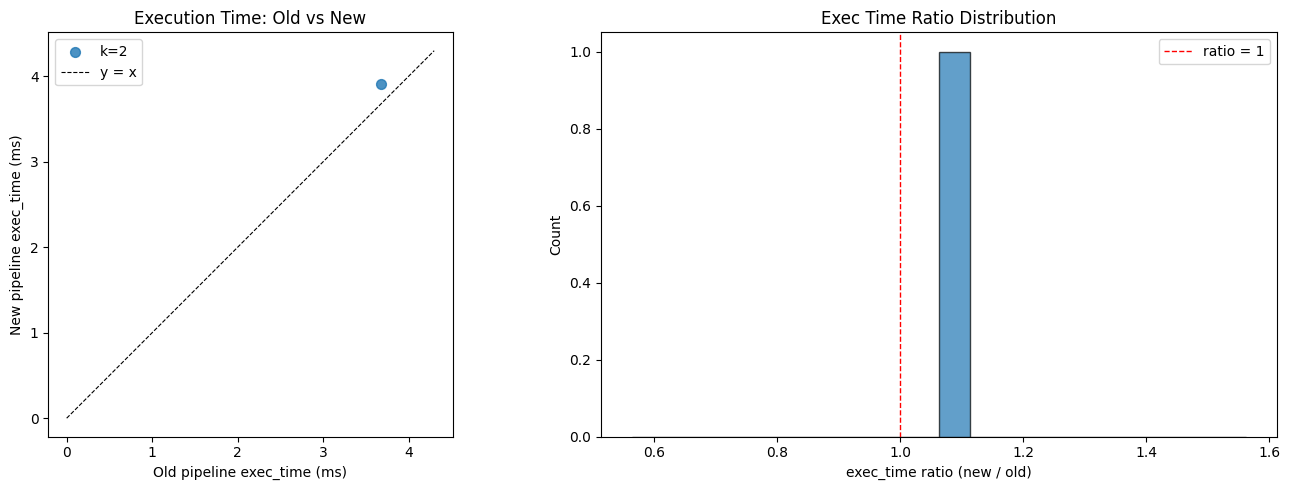

Saved → wise_pipeline_comparison.png


In [8]:
if len(df_new) > 0 and 'df_cmp' in dir() and len(df_cmp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel 1: exec_time scatter ──
    ax = axes[0]
    for k_val in sorted(df_cmp["trap_capacity"].unique()):
        mask = df_cmp["trap_capacity"] == k_val
        ax.scatter(
            df_cmp.loc[mask, "exec_time_ref"] * 1e3,
            df_cmp.loc[mask, "exec_time_new"] * 1e3,
            label=f"k={k_val}",
            s=50, alpha=0.8,
        )
    lo = 0
    hi = max(
        df_cmp["exec_time_ref"].max(),
        df_cmp["exec_time_new"].max(),
    ) * 1e3 * 1.1
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="y = x")
    ax.set_xlabel("Old pipeline exec_time (ms)")
    ax.set_ylabel("New pipeline exec_time (ms)")
    ax.set_title("Execution Time: Old vs New")
    ax.legend()
    ax.set_aspect("equal")

    # ── Panel 2: exec_time ratio histogram ──
    ax = axes[1]
    ax.hist(df_cmp["exec_time_ratio"].dropna(), bins=20, edgecolor="k", alpha=0.7)
    ax.axvline(1.0, color="r", ls="--", lw=1, label="ratio = 1")
    ax.set_xlabel("exec_time ratio (new / old)")
    ax.set_ylabel("Count")
    ax.set_title("Exec Time Ratio Distribution")
    ax.legend()

    plt.tight_layout()
    plt.savefig("wise_pipeline_comparison.png", dpi=150)
    plt.show()
    print("Saved → wise_pipeline_comparison.png")
else:
    print("Skipping plots (no comparison data).")

## 8. Full sweep: reproduce ALL reference results

Run every unique config from the reference table through the new pipeline.

**⚠️ This can be very slow** (hours for d=4 configs).
Set `RUN_FULL_SWEEP = True` when ready.

In [11]:
RUN_FULL_SWEEP = True   # ← flip to True to run all reference configs
SWEEP_D_FILTER = [2]    # ← limit to these d values (set to None for all)

if RUN_FULL_SWEEP:
    full_rows = []
    t0 = time.time()

    # Group reference rows by (d, k) so we batch search_configs calls
    groups = df_ref.groupby(["d", "trap_capacity"])

    for (d, k), grp in groups:
        if SWEEP_D_FILTER is not None and d not in SWEEP_D_FILTER:
            print(f"\n[d={d}, k={k}] ⏭  skipped (d not in {SWEEP_D_FILTER})")
            continue

        W_full, H_full = _fullgrid_dims(d, k)
        m_t = int(math.ceil(H_full / k))
        n_t = H_full

        # Use m_traps/n_traps from reference rows (may differ from _fullgrid_dims)
        # when the old pipeline used different grid-sizing logic.
        ref_m = int(grp["m_traps"].iloc[0])
        ref_n = int(grp["n_traps"].iloc[0])

        configs = [
            (int(r["lookahead"]), int(r["subgrid_width"]),
             int(r["subgrid_height"]), int(r["subgrid_increment"]))
            for _, r in grp.iterrows()
        ]
        configs = list(dict.fromkeys(configs))  # deduplicate, preserve order

        print(f"\n{'='*60}")
        print(f"[d={d}, k={k}] {len(configs)} configs, "
              f"grid=({W_full}×{H_full}), m={ref_m}, n={ref_n}")

        cores = max(1, mp.cpu_count())
        try:
            best, all_res = search_configs_best_exec_time(
                configs,
                d=d,
                m_traps=ref_m,
                n_traps=ref_n,
                trap_capacity=k,
                base_pmax_in=1,
                sat_workers_per_config=cores,
                max_total_workers=cores,
                verbose=True,
                gate_improvements=[1.0],
                num_shots=num_shots,
            )
            full_rows.extend(all_res)
        except Exception as e:
            print(f"  ❌ {e}")

    elapsed = time.time() - t0
    print(f"\nFull sweep done in {elapsed:.0f}s, {len(full_rows)} configs.")

    df_full = pd.DataFrame(full_rows)
    df_full.to_csv("wise_full_sweep_new.csv", index=False)
    print("Saved → wise_full_sweep_new.csv")
    display(df_full)
else:
    print("Full sweep disabled — set RUN_FULL_SWEEP = True to run.")


[d=2, k=2] 4 configs, grid=(4×3), m=2, n=3
[WISE-SEARCH] Process budget: 4 outer workers, peak ~9 processes (CPUs=12)
[WISE-SEARCH] Parallelism: 4 outer workers × 2 inner SAT workers (CPUs=12, configs=4)


[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.004, comp=30.5s

[WISE-SEARCH] Killed 4 processes (workers + nested children)
[WISE-SEARCH] Finished search in 654.7s; 4 configs completed.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.004, comp=30.5s
  la=1, w=4, h=3, inc=0: exec=0.006, comp=39.7s
  la=4, w=2, h=2, inc=2: exec=0.009, comp=653.0s
  la=1, w=2, h=2, inc=2: exec=0.009, comp=456.4s


[d=2, k=4] 4 configs, grid=(4×3), m=1, n=3
[WISE-SEARCH] Process budget: 4 outer workers, peak ~9 processes (CPUs=12)
[WISE-SEARCH] Parallelism: 4 outer workers × 2 inner SAT workers (CPUs=12, configs=4)


[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.003, comp=23.5s

[WISE-SEARCH] Killed 4 processes (workers + nested children)
[WISE-SEARCH] Finished search in 1622.0s; 4 configs completed.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=4, h=3, inc=0: exec=0.003, comp=23.5s
  la=1, w=2, h=2, inc=2: exec=0.005, comp=535.5s
  la=1, w=4, h=3, inc=0: exec=0.008, comp=40.9s
  la=4, w=2, h=2, inc=2: exec=0.010, comp=1620.3s


[d=2, k=8] 8 configs, grid=(8×3), m=1, n=3
[WISE-SEARCH] Process budget: 6 outer workers, peak ~13 processes (CPUs=12)
[WISE-SEARCH] Parallelism: 6 outer workers × 1 inner SAT workers (CPUs=12, configs=8)


[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=4, w=5, h=1, inc=2: exec=0.004, comp=19.3s

[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=1, w=5, h=1, inc=2: exec=0.004, comp=53.6s
  la=4, w=5, h=1, inc=2: exec=0.004, comp=19.3s
  la=4, w=8, h=3, inc=0: exec=0.004, comp=38.8s

[WISE-SEARCH] Killed 6 processes (workers + nested children)
[WISE-SEARCH] Finished search in 221.0s; 8 configs completed.
[WISE-SEARCH] Current top configs (by exec_time):
  la=1, w=5, h=1, inc=2: exec=0.004, comp=53.6s
  la=1, w=8, h=3, inc=0: exec=0.004, comp=58.5s
  la=4, w=5, h=1, inc=2: exec=0.004, comp=19.3s
  la=4, w=8, h=3, inc=0: exec=0.004, comp=38.8s
  la=1, w=3, h=1, inc=2: exec=0.005, comp=134.7s


[d=2, k=16] 13 configs, grid=(16×3), m=1, n=3
[WISE-SEARCH] Process budget: 6 outer workers, peak ~13 processes (CPUs=12)
[WISE-SEARCH] Parallelism: 6 outer workers × 1 inner SAT workers (CPUs=12, configs=13)


/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: divide by zero encountered in matmul
  overlap = new_sub @ old_sub.T
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: overflow encountered in matmul
  overlap = new_sub @ old_sub.T
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: invalid value encountered in matmul
  overlap = new_sub @ old_sub.T
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: divide by zero encountered in ma

[WISE-SEARCH] New best config found.
[WISE-SEARCH] Current top configs (by exec_time):
  la=1, w=7, h=1, inc=4: exec=0.004, comp=102.1s



/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: divide by zero encountered in matmul
  overlap = new_sub @ old_sub.T
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: overflow encountered in matmul
  overlap = new_sub @ old_sub.T
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/utils/physics.py:1226: RuntimeWarning: invalid value encountered in matmul
  overlap = new_sub @ old_sub.T


[WISE-SEARCH] Killed 6 processes (workers + nested children)
[WISE-SEARCH] Finished search in 1465.2s; 13 configs completed.
[WISE-SEARCH] Current top configs (by exec_time):
  la=1, w=7, h=1, inc=4: exec=0.004, comp=102.1s
  la=1, w=7, h=1, inc=2: exec=0.004, comp=102.2s
  la=1, w=9, h=1, inc=2: exec=0.004, comp=145.0s
  la=1, w=9, h=1, inc=4: exec=0.004, comp=145.1s
  la=1, w=16, h=3, inc=0: exec=0.004, comp=377.5s


[d=3, k=2] ⏭  skipped (d not in [2])

[d=3, k=4] ⏭  skipped (d not in [2])

[d=3, k=8] ⏭  skipped (d not in [2])

[d=3, k=16] ⏭  skipped (d not in [2])

[d=4, k=2] ⏭  skipped (d not in [2])

[d=4, k=4] ⏭  skipped (d not in [2])

[d=4, k=8] ⏭  skipped (d not in [2])

[d=4, k=16] ⏭  skipped (d not in [2])

Full sweep done in 3963s, 29 configs.
Saved → wise_full_sweep_new.csv


,lookahead,subgrid_width,subgrid_height,subgrid_increment,d,m_traps,n_traps,trap_capacity,exec_time,comp_time,reconfigTime,ElapsedTime,Operations,MeanConcurrency,QubitOperations,LogicalErrorRates,PhysicalZErrorRates,PhysicalXErrorRates,DACs,Electrodes
0,4,4,3,0,2,2,3,2,0.003906,30.477794,0.001896,0.003906,69,2.210526,65,[0.11688],[0.0],[0.0],102,300
1,1,4,3,0,2,2,3,2,0.005562,39.679359,0.003552,0.005562,69,2.175000,65,[0.11631],[0.0],[0.0],102,300
2,1,2,2,2,2,2,3,2,0.008512,456.401125,0.006782,0.008512,77,1.857143,65,[0.12075],[0.0],[0.0],102,300
3,4,2,2,2,2,2,3,2,0.008510,652.984796,0.006410,0.008510,75,1.755102,65,[0.11855],[0.0],[0.0],102,300
4,4,4,3,0,2,1,3,4,0.003415,23.472101,0.001260,0.003415,69,1.549020,65,[0.11774],[0.0],[0.0],102,270
5,1,4,3,0,2,1,3,4,0.008385,40.858865,0.004910,0.008385,69,1.410714,65,[0.11997],[0.0],[0.0],102,270
6,1,2,2,2,2,1,3,4,0.005181,535.549636,0.003046,0.005181,77,1.551724,65,[0.12086],[0.0],[0.0],102,270
7,4,2,2,2,2,1,3,4,0.010078,1620.345470,0.007888,0.010078,77,1.483333,65,[0.12568],[0.0],[0.0],102,270
8,4,5,1,2,2,1,3,8,0.004222,19.333891,0.000452,0.004222,69,1.000000,65,[0.14808],[0.0],[0.0],103,510
9,4,8,3,0,2,1,3,8,0.004222,38.827500,0.000452,0.004222,69,1.000000,65,[0.14853],[0.0],[0.0],103,510


In [12]:
# ── Compare full sweep (d=2 only) against reference ──
merge_keys = [
    "d", "trap_capacity", "m_traps", "n_traps",
    "lookahead", "subgrid_width", "subgrid_height", "subgrid_increment",
]
df_cmp_full = df_ref.merge(
    df_full, on=merge_keys, how="inner", suffixes=("_ref", "_new"),
)
df_cmp_full["exec_ratio"] = df_cmp_full["exec_time_new"] / df_cmp_full["exec_time_ref"]
df_cmp_full["reconfig_ratio"] = df_cmp_full["reconfigTime_new"] / df_cmp_full["reconfigTime_ref"]
df_cmp_full["exec_diff_us"] = (df_cmp_full["exec_time_new"] - df_cmp_full["exec_time_ref"]) * 1e6

show = df_cmp_full[merge_keys + [
    "exec_time_ref", "exec_time_new", "exec_ratio", "exec_diff_us",
    "reconfigTime_ref", "reconfigTime_new", "reconfig_ratio",
]].sort_values("exec_ratio", ascending=False)

print(f"Matched {len(df_cmp_full)} / {len(df_ref[df_ref['d'].isin([2])])} reference configs (d=2)")
print(f"\nExec-time ratio stats (new/old, <1 = better):")
print(show["exec_ratio"].describe().round(4))
print(f"\nBetter (ratio<0.95): {(show['exec_ratio']<0.95).sum()}")
print(f"Same   (0.95-1.05):  {((show['exec_ratio']>=0.95)&(show['exec_ratio']<=1.05)).sum()}")
print(f"Worse  (ratio>1.05): {(show['exec_ratio']>1.05).sum()}")
display(show.round(4))

Matched 29 / 29 reference configs (d=2)

Exec-time ratio stats (new/old, <1 = better):
count    29.0000
mean      1.0393
std       0.2379
min       0.7228
25%       0.8631
50%       1.0194
75%       1.0631
max       1.7324
Name: exec_ratio, dtype: float64

Better (ratio<0.95): 10
Same   (0.95-1.05):  5
Worse  (ratio>1.05): 14


,d,trap_capacity,m_traps,n_traps,lookahead,subgrid_width,subgrid_height,subgrid_increment,exec_time_ref,exec_time_new,exec_ratio,exec_diff_us,reconfigTime_ref,reconfigTime_new,reconfig_ratio
4,2,4,1,3,1,4,3,0,0.0048,0.0084,1.7324,3545.0,0.0028,0.0049,1.7599
14,2,8,1,3,4,3,1,2,0.0060,0.0090,1.4925,2968.0,0.0023,0.0052,2.3156
15,2,8,1,3,4,3,1,4,0.0060,0.0090,1.4925,2968.0,0.0023,0.0052,2.3156
7,2,4,1,3,4,2,2,2,0.0079,0.0101,1.2809,2210.0,0.0048,0.0079,1.6475
28,2,16,1,3,4,5,1,2,0.0064,0.0079,1.2301,1484.0,0.0027,0.0042,1.5537
20,2,16,1,3,1,5,1,4,0.0056,0.0067,1.1892,1060.0,0.0018,0.0029,1.5786
27,2,16,1,3,1,5,1,2,0.0056,0.0067,1.1892,1060.0,0.0018,0.0029,1.5786
2,2,2,2,3,4,4,3,0,0.0037,0.0039,1.0631,232.0,0.0017,0.0019,1.1259
25,2,16,1,3,4,9,1,4,0.0040,0.0042,1.0529,212.0,0.0002,0.0005,1.8833
24,2,16,1,3,4,9,1,2,0.0040,0.0042,1.0529,212.0,0.0002,0.0005,1.8833


In [13]:
# ── Deep regression analysis ──
import pandas as pd, numpy as np

c = df_cmp_full.copy()
c["is_fullgrid"] = c["subgrid_increment"] == 0
c["sg_area"] = c["subgrid_width"] * c["subgrid_height"]
c["grid_area"] = c["n_traps"] * c["m_traps"] * c["trap_capacity"]  # total ion slots
c["sg_fraction"] = c["sg_area"] / (c["n_traps"] * c["m_traps"] * c["trap_capacity"])
c["n_traps_x_m_traps"] = c["n_traps"].astype(str) + "x" + c["m_traps"].astype(str)
c["reconfig_diff_us"] = (c["reconfigTime_new"] - c["reconfigTime_ref"]) * 1e6
c["exec_diff_us"] = (c["exec_time_new"] - c["exec_time_ref"]) * 1e6
c["reconfig_pct_of_exec_diff"] = np.where(
    c["exec_diff_us"].abs() > 0,
    c["reconfig_diff_us"] / c["exec_diff_us"] * 100,
    0
)
c["bucket"] = np.where(c["exec_ratio"] < 0.95, "BETTER",
              np.where(c["exec_ratio"] > 1.05, "WORSE", "SAME"))

# --- Factor analysis ---
print("="*70)
print("PIVOT: lookahead × bucket")
print(pd.crosstab(c["lookahead"], c["bucket"]))
print()
print("PIVOT: trap_capacity × bucket")
print(pd.crosstab(c["trap_capacity"], c["bucket"]))
print()
print("PIVOT: is_fullgrid × bucket")
print(pd.crosstab(c["is_fullgrid"], c["bucket"]))
print()
print("PIVOT: lookahead × is_fullgrid × bucket")
print(pd.crosstab([c["lookahead"], c["is_fullgrid"]], c["bucket"]))
print()

# --- Reconfig contribution ---
print("="*70)
print("WORSE configs — reconfig contribution to exec increase:")
worse = c[c["bucket"]=="WORSE"].sort_values("exec_ratio", ascending=False)
display(worse[["trap_capacity", "lookahead", "subgrid_width", "subgrid_height",
               "subgrid_increment", "is_fullgrid",
               "exec_diff_us", "reconfig_diff_us", "reconfig_pct_of_exec_diff",
               "exec_ratio", "reconfig_ratio"]].round(1))

print()
print("BETTER configs — reconfig contribution to exec decrease:")
better = c[c["bucket"]=="BETTER"].sort_values("exec_ratio")
display(better[["trap_capacity", "lookahead", "subgrid_width", "subgrid_height",
                "subgrid_increment", "is_fullgrid",
                "exec_diff_us", "reconfig_diff_us", "reconfig_pct_of_exec_diff",
                "exec_ratio", "reconfig_ratio"]].round(1))

# --- Key hypothesis: base_pmax=1 vs base_pmax=R=4 ---
# With base_pmax=1, P_max search starts at 1. With old base_pmax=R=4, it starts at 4.
# For d=2 the grid is n=3,m=4, so limit_pmax = base + n + m.
# New: range [1, 1+3+4=8], Old: range [4, 4+3+4=11]
# The old module never tries P_max < R.
print("="*70)
print("Key structural comparison:")
n_grid, m_grid = 3, 4  # for d=2
print(f"  Grid: n={n_grid}, m={m_grid}")  
print(f"  NEW: base_pmax=1, range=[1, {1+n_grid+m_grid}], step≈{max(int(np.floor((n_grid+m_grid)/4)),1)}")
print(f"  OLD: base_pmax=R=4, range=[4, {4+n_grid+m_grid}], step=1 (sequential)")
print(f"  NEW round-0 P_bound: P_max + n + m = P_max + {n_grid+m_grid}")
print(f"  OLD round-0 P_bound: P_max (flat, no padding)")
print()
print("  NEW searches 8 P_max values × 1 cap_factor = 8 configs (for full-grid)")
print("  OLD searches 8 P_max values × 1 cap_factor = 8 configs (for full-grid)")
print()
print("  But the P_bounds formula means NEW round 0 gives P_max+7 passes")
print("  while OLD round 0 gives just P_max passes.")
print("  This changes the SAT solution space for round 0.")

PIVOT: lookahead × bucket
bucket     BETTER  SAME  WORSE
lookahead                     
1               8     4      3
4               2     1     11

PIVOT: trap_capacity × bucket
bucket         BETTER  SAME  WORSE
trap_capacity                     
2                   1     2      1
4                   2     0      2
8                   3     1      4
16                  4     2      7

PIVOT: is_fullgrid × bucket
bucket       BETTER  SAME  WORSE
is_fullgrid                     
False             6     4     11
True              4     1      3

PIVOT: lookahead × is_fullgrid × bucket
bucket                 BETTER  SAME  WORSE
lookahead is_fullgrid                     
1         False             6     3      2
          True              2     1      1
4         False             0     1      9
          True              2     0      2

WORSE configs — reconfig contribution to exec increase:


,trap_capacity,lookahead,subgrid_width,subgrid_height,subgrid_increment,is_fullgrid,exec_diff_us,reconfig_diff_us,reconfig_pct_of_exec_diff,exec_ratio,reconfig_ratio
4,4,1,4,3,0,True,3545.0,2120.0,59.8,1.7,1.8
14,8,4,3,1,2,False,2968.0,2968.0,100.0,1.5,2.3
15,8,4,3,1,4,False,2968.0,2968.0,100.0,1.5,2.3
7,4,4,2,2,2,False,2210.0,3100.0,140.3,1.3,1.6
28,16,4,5,1,2,False,1484.0,1484.0,100.0,1.2,1.6
20,16,1,5,1,4,False,1060.0,1060.0,100.0,1.2,1.6
27,16,1,5,1,2,False,1060.0,1060.0,100.0,1.2,1.6
2,2,4,4,3,0,True,232.0,212.0,91.4,1.1,1.1
12,8,4,5,1,2,False,212.0,212.0,100.0,1.1,1.9
13,8,4,8,3,0,True,212.0,212.0,100.0,1.1,1.9



BETTER configs — reconfig contribution to exec decrease:


,trap_capacity,lookahead,subgrid_width,subgrid_height,subgrid_increment,is_fullgrid,exec_diff_us,reconfig_diff_us,reconfig_pct_of_exec_diff,exec_ratio,reconfig_ratio
6,4,4,4,3,0,True,-1310.0,0.0,-0.0,0.7,1.0
21,16,1,16,3,0,True,-1455.0,-2040.0,140.2,0.7,0.1
5,4,1,2,2,2,False,-1732.0,-1742.0,100.6,0.7,0.6
9,8,1,8,3,0,True,-1022.0,-1232.0,120.5,0.8,0.2
10,8,1,3,1,4,False,-1272.0,-1272.0,100.0,0.8,0.6
11,8,1,3,1,2,False,-1272.0,-1272.0,100.0,0.8,0.6
18,16,1,9,1,2,False,-636.0,-636.0,100.0,0.9,0.3
19,16,1,9,1,4,False,-636.0,-636.0,100.0,0.9,0.3
1,2,1,2,2,2,False,-1275.0,-1020.0,80.0,0.9,0.9
26,16,4,16,3,0,True,-285.0,-510.0,178.9,0.9,0.3


Key structural comparison:
  Grid: n=3, m=4
  NEW: base_pmax=1, range=[1, 8], step≈1
  OLD: base_pmax=R=4, range=[4, 11], step=1 (sequential)
  NEW round-0 P_bound: P_max + n + m = P_max + 7
  OLD round-0 P_bound: P_max (flat, no padding)

  NEW searches 8 P_max values × 1 cap_factor = 8 configs (for full-grid)
  OLD searches 8 P_max values × 1 cap_factor = 8 configs (for full-grid)

  But the P_bounds formula means NEW round 0 gives P_max+7 passes
  while OLD round 0 gives just P_max passes.
  This changes the SAT solution space for round 0.


## 9. Single-config quick test

Run a single `run_single_config()` call directly to verify the pipeline
end-to-end without multiprocessing overhead.

In [ ]:
# Pick a small reference config for quick testing
# d=2, k=2, la=1, subgrid=(4,3,0) → old exec_time ≈ 0.005659
print("Running single config: d=2, k=2, la=1, subgrid=(4,3,0) ...")
t_start = time.perf_counter()

exec_time, comp_time, results, reconfig_time = run_single_config(
    lookahead=1,
    subgrid_width=4,
    subgrid_height=3,
    subgrid_increment=0,
    d=2,
    m_traps=2,
    n_traps=3,
    trap_capacity=2,
    gate_improvements=[1.0],
    num_shots=num_shots,
)

t_elapsed = time.perf_counter() - t_start

print(f"\nResults:")
print(f"  exec_time    : {exec_time:.6f}   (ref: 0.005659)")
print(f"  comp_time    : {comp_time:.2f}s    (ref: ~24s)")
print(f"  reconfigTime : {reconfig_time}       (ref: 0.003724)")
print(f"  wall-clock   : {t_elapsed:.2f}s")
print(f"  results keys : {list(results.keys())}")
for k_res, v_res in results.items():
    print(f"    {k_res}: {v_res}")

Running single config: d=2, k=2, la=1, subgrid=(4,3,0) ...


[DIAG] configs=8, P_max range=[1,8], has_boundary=False, eff_cap_steps=1, step=1, n=3, m=4, R=1


SAT Configs:   0%|          | 0/8 [00:00<?, ?cfg/s]

[DIAG] Total results=8, SAT results=5
[DIAG]   result[0]: P_max=8, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 8)
[DIAG]   result[1]: P_max=1, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[2]: P_max=7, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 7)
[DIAG]   result[3]: P_max=2, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[4]: P_max=6, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 6)
[DIAG]   result[5]: P_max=3, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[6]: P_max=5, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 5)
[DIAG]   result[7]: P_max=4, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 4)
[DIAG] configs=8, P_max range=[1,8], has_boundary=False, eff_cap_steps=1, step=1, n=3, m=4, R=1
[DIAG] Total results=8, SAT results=6
[DIAG]   result[0]: P_max=8, cap_fact


Results:
  exec_time    : 0.005638   (ref: 0.005659)
  comp_time    : 29.27s    (ref: ~24s)
  reconfigTime : 0.0036380000000000006       (ref: 0.003724)
  wall-clock   : 29.28s
  results keys : ['ElapsedTime', 'Operations', 'MeanConcurrency', 'QubitOperations', 'LogicalErrorRates', 'PhysicalZErrorRates', 'PhysicalXErrorRates', 'DACs', 'Electrodes']
    ElapsedTime: 0.005638000000000001
    Operations: 69
    MeanConcurrency: 2.236842105263158
    QubitOperations: 65
    LogicalErrorRates: [0.11776]
    PhysicalZErrorRates: [0.0]
    PhysicalXErrorRates: [0.0]
    DACs: 102
    Electrodes: 300


[DIAG] Total results=8, SAT results=7
[DIAG]   result[0]: P_max=8, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 8)
[DIAG]   result[1]: P_max=1, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[2]: P_max=7, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 7)
[DIAG]   result[3]: P_max=2, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 2)
[DIAG]   result[4]: P_max=6, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 6)
[DIAG]   result[5]: P_max=3, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 3)
[DIAG]   result[6]: P_max=5, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 5)
[DIAG]   result[7]: P_max=4, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 4)


## 10. TrappedIonCompiler API (low-level)

Demonstrate the actual `TrappedIonCompiler.compile()` entry point
with a WISE architecture directly (what `run_single_config()` does internally).

In [ ]:
# Build the pipeline manually — this is what run_single_config() does internally
d_test = 2
k_test = 2
W, H = _fullgrid_dims(d_test, k_test)
m_t = int(math.ceil(H / k_test))

# 1. Generate ideal circuit
ideal = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=d_test,
)
print(f"Ideal circuit: {ideal.num_qubits} qubits, {len(ideal)} instructions")

# 2. Build WISE architecture
wise_arch = QCCDWiseArch(m=m_t, n=H, k=k_test)
arch = WISEArchitecture(wise_config=wise_arch)
print(f"Architecture: m={m_t}, n={H}, k={k_test}")

# 3. Build routing config
rc = WISERoutingConfig(
    subgridsize=(4, 3, 0),
    lookahead=1,
)
print(f"Routing config: subgrid={rc.subgridsize}, lookahead={rc.lookahead}")

# 4. Build compiler and set routing kwargs (this is how run_single_config does it)
compiler = TrappedIonCompiler(arch, is_wise=True, wise_config=wise_arch)
compiler.routing_kwargs = dict(
    lookahead=1,
    subgridsize=(4, 3, 0),
    base_pmax_in=None,
    routing_config=rc,
    stop_event=None,
)

# 5. Compile (decompose → map → route → schedule)
t0 = time.perf_counter()
compiled = compiler.compile(ideal)
comp_time_low = time.perf_counter() - t0

print(f"\nCompilation done in {comp_time_low:.2f}s")
print(f"Compiled circuit type: {type(compiled).__name__}")

# 6. Extract metrics from CompiledCircuit
scheduled = compiled.scheduled
exec_time_low = scheduled.total_duration
reconfig_time_low = scheduled.routed_circuit.metadata.get('reconfig_time', 0.0)
print(f"exec_time    : {exec_time_low:.6f}   (ref: 0.005659)")
print(f"reconfigTime : {reconfig_time_low}       (ref: 0.003724)")

Ideal circuit: 13 qubits, 26 instructions
Architecture: m=2, n=3, k=2
Routing config: subgrid=(4, 3, 0), lookahead=1


[DIAG] configs=8, P_max range=[1,8], has_boundary=False, eff_cap_steps=1, step=1, n=3, m=4, R=1


SAT Configs:   0%|          | 0/8 [00:00<?, ?cfg/s]

[DIAG] Total results=8, SAT results=5
[DIAG]   result[0]: P_max=8, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 8)
[DIAG]   result[1]: P_max=1, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[2]: P_max=7, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 7)
[DIAG]   result[3]: P_max=2, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[4]: P_max=6, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 6)
[DIAG]   result[5]: P_max=3, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[6]: P_max=5, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 5)
[DIAG]   result[7]: P_max=4, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.000802, 4)
[DIAG] configs=8, P_max range=[1,8], has_boundary=False, eff_cap_steps=1, step=1, n=3, m=4, R=1
[DIAG] Total results=8, SAT results=6
[DIAG]   result[0]: P_max=8, cap_fact


Compilation done in 25.68s
Compiled circuit type: CompiledCircuit
exec_time    : 0.005638   (ref: 0.005659)
reconfigTime : 0.0036380000000000006       (ref: 0.003724)


[DIAG] Total results=8, SAT results=7
[DIAG]   result[0]: P_max=8, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 8)
[DIAG]   result[1]: P_max=1, cap_factor=1.0, usage=None, sat=False, status=unsat, score=N/A
[DIAG]   result[2]: P_max=7, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 7)
[DIAG]   result[3]: P_max=2, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 2)
[DIAG]   result[4]: P_max=6, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 6)
[DIAG]   result[5]: P_max=3, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 3)
[DIAG]   result[6]: P_max=5, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 5)
[DIAG]   result[7]: P_max=4, cap_factor=1.0, usage=[2], sat=True, status=ok, score=(-1.0, 0.0011, 4)


## 11. Resource estimation

Compute DAC / electrode counts using `NDE_LZ`, `NDE_JZ`, `NSE_Z` constants
(same formula as `_route_and_simulate` in `best_effort_compilation_WISE.py`).

In [ ]:
resource_rows = []
for _, row in df_ref.drop_duplicates(subset=["d", "trap_capacity", "m_traps", "n_traps"]).iterrows():
    d, k = int(row["d"]), int(row["trap_capacity"])
    m, n = int(row["m_traps"]), int(row["n_traps"])
    num_ions = m * n * k
    num_traps = m * n

    # Electrode counts: same formula used by _route_and_simulate / qccd_circuit
    Nde = num_traps * NDE_LZ + (num_traps - 1) * NDE_JZ      # DC electrodes
    Nse = num_traps * NSE_Z                                    # shim electrodes
    DACs = int(min(100, Nde) + np.ceil(Nse / 100))
    Electrodes = int(Nde + Nse)

    resource_rows.append({
        "d": d, "k": k, "m": m, "n": n,
        "num_ions": num_ions, "num_traps": num_traps,
        "Nde": Nde, "Nse": Nse,
        "DACs": DACs, "Electrodes": Electrodes,
    })

df_hw = pd.DataFrame(resource_rows)
print(f"Hardware resource estimates (NDE_LZ={NDE_LZ}, NDE_JZ={NDE_JZ}, NSE_Z={NSE_Z}):")
display(df_hw)

Hardware resource estimates (NDE_LZ=10, NDE_JZ=20, NSE_Z=10):


,d,k,m,n,num_ions,num_traps,Nde,Nse,DACs,Electrodes
0,2,2,2,3,12,6,160,60,101,220
1,2,4,1,3,12,3,70,30,71,100
2,2,8,1,3,24,3,70,30,71,100
3,2,16,1,3,48,3,70,30,71,100
4,3,2,3,5,30,15,430,150,102,580
5,3,4,2,5,40,10,280,100,101,380
6,3,8,1,5,40,5,130,50,101,180
7,3,16,1,5,80,5,130,50,101,180
8,4,2,3,6,36,18,520,180,102,700
9,4,4,2,6,48,12,340,120,102,460


## 12. Reference data plots

Visualise the reference data: exec_time vs trap_capacity, coloured by d.

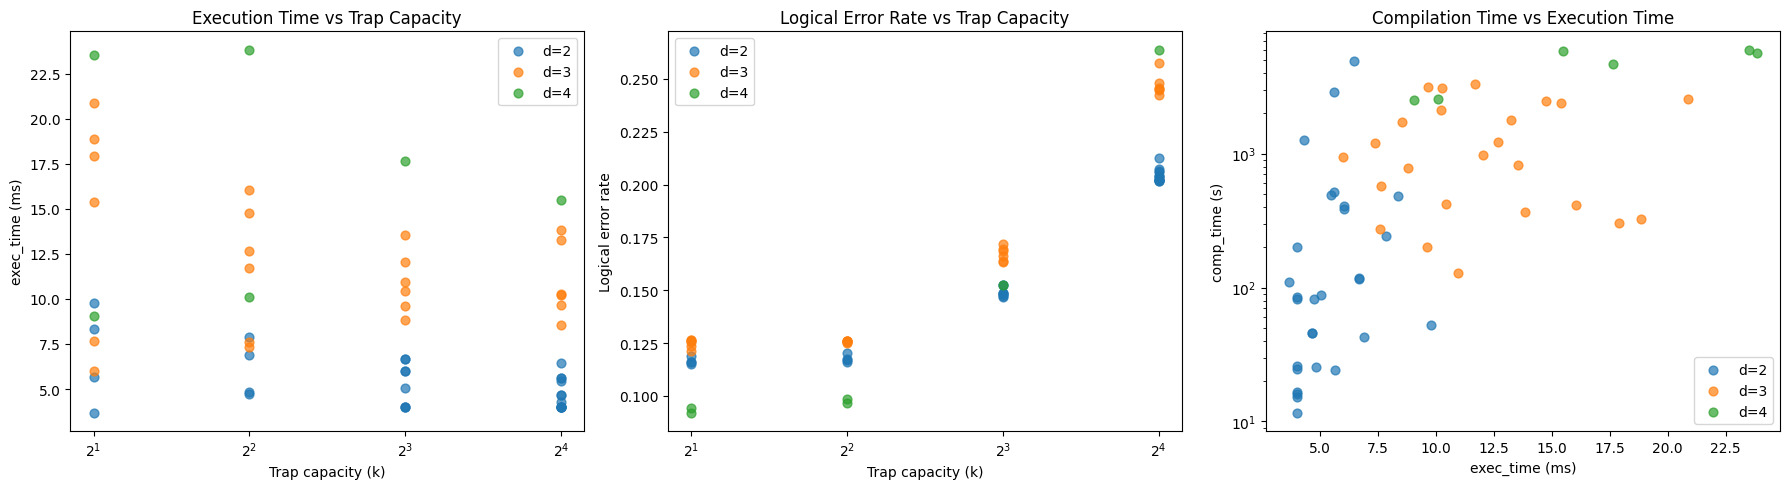

Saved → wise_reference_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: exec_time vs trap_capacity ──
ax = axes[0]
for d_val in sorted(df_ref["d"].unique()):
    mask = df_ref["d"] == d_val
    ax.scatter(
        df_ref.loc[mask, "trap_capacity"],
        df_ref.loc[mask, "exec_time"] * 1e3,
        label=f"d={d_val}", s=40, alpha=0.7,
    )
ax.set_xlabel("Trap capacity (k)")
ax.set_ylabel("exec_time (ms)")
ax.set_title("Execution Time vs Trap Capacity")
ax.legend()
ax.set_xscale("log", base=2)

# ── Panel 2: logicalerror vs trap_capacity ──
ax = axes[1]
for d_val in sorted(df_ref["d"].unique()):
    mask = df_ref["d"] == d_val
    ax.scatter(
        df_ref.loc[mask, "trap_capacity"],
        df_ref.loc[mask, "logicalerror"],
        label=f"d={d_val}", s=40, alpha=0.7,
    )
ax.set_xlabel("Trap capacity (k)")
ax.set_ylabel("Logical error rate")
ax.set_title("Logical Error Rate vs Trap Capacity")
ax.legend()
ax.set_xscale("log", base=2)

# ── Panel 3: comp_time vs exec_time ──
ax = axes[2]
for d_val in sorted(df_ref["d"].unique()):
    mask = df_ref["d"] == d_val
    ax.scatter(
        df_ref.loc[mask, "exec_time"] * 1e3,
        df_ref.loc[mask, "comp_time"],
        label=f"d={d_val}", s=40, alpha=0.7,
    )
ax.set_xlabel("exec_time (ms)")
ax.set_ylabel("comp_time (s)")
ax.set_title("Compilation Time vs Execution Time")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.savefig("wise_reference_overview.png", dpi=150)
plt.show()
print("Saved → wise_reference_overview.png")

## Summary

| Component | Old pipeline | New pipeline (`best_effort_compilation_WISE`) |
|-----------|-------------|----------------------------------------------|
| `run_single_config()` | `best_effort_compilation.py` | `best_effort_compilation_WISE.run_single_config()` |
| `search_configs()` | `search_configs_best_exec_time()` | `best_effort_compilation_WISE.search_configs_best_exec_time()` |
| Resource estimation | inline `NDE_LZ/NDE_JZ/NSE_Z` | Same constants via `trapped_ion.NDE_LZ/NDE_JZ/NSE_Z` |
| Compilation | `QCCDCircuit.processCircuitWiseArch()` | `TrappedIonCompiler.compile()` |
| Simulation | `circuit.simulate()` | `TrappedIonExperiment.apply_hardware_noise()` + decode |
| Grid dims helper | `_fullgrid_dims()` | Same (portable) |

The SAT solver core, routing, and scheduling are shared between
pipelines — differences are in the glue code and API surface.